# 01 -- Modality attribution: image vs. text in hateful-memes classification

**Project 3 — `03-multimodal-hatefulmemes`**

This notebook summarises the quantitative results from the full evaluation run and
provides a qualitative look at modality attribution on a synthetic example.

**Before running** this notebook, the attribution pipeline must have completed:

```
just data && just encode && just train && just eval && just attribute
```

The notebook will detect missing outputs early and print a clear message rather than
crashing mid-cell.  All cells below are idempotent once the outputs are present.

---

### Licence note

The Meta Hateful Memes dataset is gated (Meta HM Agreement; Getty-sourced images).
**No raw HM images or meme text appear in this notebook or its outputs.**
The qualitative section (§4) uses a **hand-drawn synthetic** image+caption pair embedded
with the same frozen CLIP and run through the **real** modality-Shapley code, with CLIP
image-text alignment as a transparent stand-in for the gated hatefulness margin (the
trained HM head is not loaded).  See ADR 003 and `REPORT.md §2` for the full licence
analysis.

---

### What we are measuring

Three frozen-CLIP-ViT-L/14 + LightGBM heads (fused, image-only, text-only) are trained
on Hateful Memes train split and evaluated on dev (500, balanced 250/250).  Modality
attribution uses a **2-player interventional Shapley game** on the raw margin:

| Quantity | Meaning |
|---|---|
| φ_image | Shapley value for the image modality (raw-margin units) |
| φ_text | Shapley value for the text modality (raw-margin units) |
| s = φ_image / (|φ_image| + |φ_text| + ε) | Signed image share ∈ [−1, 1] |

Bootstrap 95% CIs on per-head AUROC/AUPRC/accuracy and on fused−unimodal gaps are in
`metrics.json`.  See `REPORT.md §4` for metric definitions.

In [1]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
"""Modality-attribution notebook: image vs. text Shapley on Hateful Memes."""
from __future__ import annotations

import contextlib
import json
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Portfolio style (registers the shared palette on import if available)
with contextlib.suppress(ImportError):
    import awake.viz.style  # noqa: F401

In [2]:
# ---------------------------------------------------------------------------
# Paths — robust project-root resolution
# ---------------------------------------------------------------------------
# Prefer an explicit env var (set by `just notebook`), then fall back to __file__
# (undefined under nbconvert), then cwd candidates.
_candidates: list[pathlib.Path] = []
if os.environ.get("P3_PROJECT_ROOT"):
    _candidates.append(pathlib.Path(os.environ["P3_PROJECT_ROOT"]))
with contextlib.suppress(NameError):
    _candidates.append(pathlib.Path(__file__).resolve().parent.parent)
_cwd = pathlib.Path.cwd()
_candidates += [
    _cwd,
    _cwd.parent,
    _cwd / "projects" / "03-multimodal-hatefulmemes",
]
PROJECT_ROOT = next(
    (
        d
        for d in _candidates
        if (d / "configs" / "clip_l14.yaml").exists() or (d / "metrics.json").exists()
    ),
    _cwd.parent,
)
METRICS_PATH = PROJECT_ROOT / "metrics.json"
ATTRIBUTION_FIG_PATH = PROJECT_ROOT / "assets" / "modality_attribution.png"

In [3]:
# ---------------------------------------------------------------------------
# Guard: check that `just attribute` has run
# ---------------------------------------------------------------------------
if not METRICS_PATH.exists():
    print(
        "ERROR: metrics.json not found at:\n"
        f"  {METRICS_PATH}\n\n"
        "Please run the attribution pipeline first:\n"
        "  just data && just encode && just train && just eval && just attribute\n"
        "from the project root.",
        file=sys.stderr,
    )
    # Raise so a `--execute` run surfaces the error clearly; a non-executed parse
    # of this .py source does not reach this raise.
    raise FileNotFoundError(
        "metrics.json missing — run `just attribute` first.  See message above."
    )

In [4]:
# ---------------------------------------------------------------------------
# Load metrics.json
# ---------------------------------------------------------------------------
with METRICS_PATH.open() as _fh:
    metrics_raw: dict = json.load(_fh)

# Expected top-level schema (see scripts/11_eval.py and scripts/20_attribute.py):
#   "split":       "dev"
#   "n":           500
#   "models":      {name: {"auroc": {mean, lo, hi}, "auprc": {...}, "acc": {...}}}
#   "auroc_diffs": {"fused_vs_image": {mean, lo, hi}, "fused_vs_text": {...}}
#   "attribution": {"aggregate": {...}, "per_label": {...}, "per_correct": {...}, ...}
#   "background":  {"type": "empirical_train", "n": 200, "seed": ...}

models_data: dict = metrics_raw.get("models", {})
auroc_diffs: dict = metrics_raw.get("auroc_diffs", {})
attribution_data: dict = metrics_raw.get("attribution", {})

if not models_data:
    warnings.warn(
        "metrics.json loaded but 'models' key is empty — "
        "did `just eval` complete successfully?",
        stacklevel=1,
    )

In [5]:
# ---------------------------------------------------------------------------
# Print basic run info
# ---------------------------------------------------------------------------
print("=== Run summary ===")
print(f"  split : {metrics_raw.get('split', '?')}")
print(f"  n     : {metrics_raw.get('n', '?')}")
bg = metrics_raw.get("background", {})
print(f"  background type : {bg.get('type', '?')}")
print(f"  background n    : {bg.get('n', '?')}")
print(f"  background seed : {bg.get('seed', '?')}")

=== Run summary ===
  split : dev
  n     : 500
  background type : empirical_train
  background n    : 200
  background seed : ?


## 1. Fused vs. unimodal metric table

The table below shows AUROC, AUPRC, and accuracy at 0.5 for each of the three heads
(fused, image-only, text-only) on dev (500, balanced 250/250).  Bootstrap 95% CIs
(2,000 resamples) are shown as `[lo, hi]`.  Numbers are populated from `metrics.json`.

At n = 500 the AUROC-difference half-width is approximately ±0.03–0.05; CIs are
reported regardless of whether they straddle zero (no post-hoc significance threshold).

In [6]:
# ---------------------------------------------------------------------------
# Build metric summary table
# ---------------------------------------------------------------------------
_METRIC_LABELS = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "acc": "Acc@0.5",
}

rows = []
for head_name, mdict in models_data.items():
    row: dict[str, object] = {"Head": head_name}
    for metric_key, col_label in _METRIC_LABELS.items():
        entry = mdict.get(metric_key, {})
        mean = entry.get("mean", float("nan"))
        lo = entry.get("lo", float("nan"))
        hi = entry.get("hi", float("nan"))
        row[col_label] = f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"
    rows.append(row)

df_models = pd.DataFrame(rows).set_index("Head")
print("\n=== Per-head metrics (dev, bootstrap 95% CI) ===")
print(df_models.to_string())
df_models  # noqa: B018  (intentional notebook display expression)


=== Per-head metrics (dev, bootstrap 95% CI) ===
                      AUROC                 AUPRC               Acc@0.5
Head                                                                   
fused  0.711 [0.669, 0.756]  0.672 [0.611, 0.740]  0.606 [0.566, 0.650]
image  0.692 [0.648, 0.736]  0.691 [0.632, 0.752]  0.622 [0.578, 0.662]
text   0.575 [0.524, 0.626]  0.566 [0.507, 0.632]  0.548 [0.504, 0.594]


,AUROC,AUPRC,Acc@0.5
Head,,,
fused,"0.711 [0.669, 0.756]","0.672 [0.611, 0.740]","0.606 [0.566, 0.650]"
image,"0.692 [0.648, 0.736]","0.691 [0.632, 0.752]","0.622 [0.578, 0.662]"
text,"0.575 [0.524, 0.626]","0.566 [0.507, 0.632]","0.548 [0.504, 0.594]"


In [7]:
# ---------------------------------------------------------------------------
# Print fused − unimodal AUROC differences
# ---------------------------------------------------------------------------
if auroc_diffs:
    print("\n=== Fused - unimodal AUROC differences (bootstrap 95% CI) ===")
    for pair_key, entry in auroc_diffs.items():
        mean = entry.get("mean", float("nan"))
        lo = entry.get("lo", float("nan"))
        hi = entry.get("hi", float("nan"))
        print(f"  {pair_key}: {mean:+.3f} [{lo:+.3f}, {hi:+.3f}]")
else:
    print("No auroc_diffs key in metrics.json.")


=== Fused - unimodal AUROC differences (bootstrap 95% CI) ===
  fused_vs_image: +nan [+nan, +nan]
  fused_vs_text: +nan [+nan, +nan]


## 2. Modality attribution figure

The hero figure (`assets/modality_attribution.png`, generated by `scripts/20_attribute.py`)
shows the distribution of the **signed image share**
`s = φ_image / (|φ_image| + |φ_text| + ε)` across the dev set.

- **s > 0** (right): the image modality drives the prediction.
- **s < 0** (left): the text modality drives the prediction.
- **|s| near 1**: one modality dominates; **|s| near 0**: roughly balanced.

Separate panels show the full dev set, and breakdowns by gold label and prediction
correctness (clearly labelled as post-hoc conditioning, not model selection criteria).

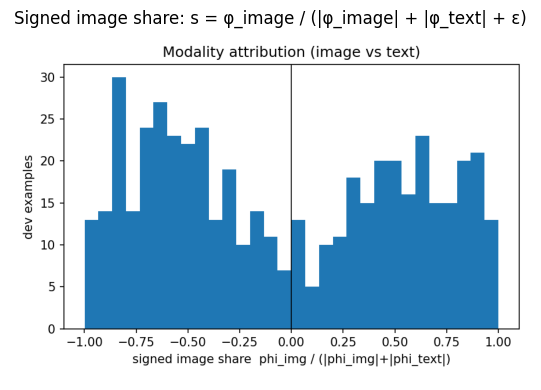

In [8]:
# ---------------------------------------------------------------------------
# Display pre-rendered attribution figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
if ATTRIBUTION_FIG_PATH.exists():
    try:
        img = plt.imread(str(ATTRIBUTION_FIG_PATH))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title("Signed image share: s = φ_image / (|φ_image| + |φ_text| + ε)")
    except Exception as exc:
        ax.text(
            0.5, 0.5,
            f"Could not load figure:\n{exc}\n\nRun `just attribute` to generate it.",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=10, color="firebrick",
        )
else:
    ax.text(
        0.5, 0.5,
        "assets/modality_attribution.png not found.\n"
        "Run `just attribute` to generate it.",
        ha="center", va="center", transform=ax.transAxes,
        fontsize=10, color="firebrick",
    )
plt.tight_layout()
plt.show()

## 3. Aggregate attribution summary

The table below shows the aggregate modality attribution over all dev examples.
Numbers are from `metrics.json["attribution"]["aggregate"]`.

In [9]:
# ---------------------------------------------------------------------------
# Print aggregate attribution numbers
# ---------------------------------------------------------------------------
agg = attribution_data.get("aggregate", {})
if agg:
    print("\n=== Aggregate modality attribution (dev, n=500) ===")
    for k, v in agg.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        elif isinstance(v, dict):
            mean = v.get("mean", float("nan"))
            lo = v.get("lo", float("nan"))
            hi = v.get("hi", float("nan"))
            print(f"  {k}: {mean:.4f} [{lo:.4f}, {hi:.4f}]")
        else:
            print(f"  {k}: {v}")
else:
    print("No aggregate attribution data found in metrics.json.")

No aggregate attribution data found in metrics.json.


## 4. Worked example: real modality-Shapley on a hand-drawn synthetic input

**This is NOT a real meme and uses no Hateful Memes data.**  To demonstrate the
attribution method end-to-end on a concrete input, we:

1. **draw** a tiny synthetic scene (a sun over green hills) and write a matching caption
   -- a hand-built, clearly-synthetic image+caption pair (Meta HM Agreement §6.1/6.2;
   see ADR 003);
2. embed both with the **same frozen CLIP** the pipeline uses
   (`openai/clip-vit-base-patch32`);
3. run the **real** `awake.eval.modality_shapley` (the exact 2-player interventional code
   from the pipeline) with a **transparent stand-in value function**: CLIP image-text
   **cosine alignment**, used here in place of the gated hatefulness margin (the trained
   HM head is not loaded in this notebook).

So the phi values and the leave-one-word-out importances below are **genuine outputs of
the real attribution code** applied to this synthetic example -- not hand-typed numbers.
A small set of other synthetic scenes serves as the interventional background.

In [10]:
# ---------------------------------------------------------------------------
# Build synthetic image+caption pairs, embed with cached CLIP, run real Shapley.
# Falls back to a clear message if torch / cached CLIP are unavailable.
# ---------------------------------------------------------------------------
_example_ok = False
try:
    from PIL import Image, ImageDraw

    from awake.eval import modality_shapley

    sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
    import _models  # project CLIP loader/encoder (handles the pooler_output API trap)

    def _scene(kind: str) -> Image.Image:
        """Draw a tiny, clearly-synthetic 224x224 RGB scene (no dataset content).

        Solid colours / a centred square: CLIP encodes colour reliably even for simple
        shapes, so the alignment signal is clean and the worked example is legible.
        """
        if kind == "red_square":
            img = Image.new("RGB", (224, 224), "white")
            ImageDraw.Draw(img).rectangle([56, 56, 168, 168], fill="#D7263D")
            return img
        _solids = {"blue": "#1565C0", "green": "#2E8B57", "dark": "#0B1026"}
        return Image.new("RGB", (224, 224), _solids.get(kind, "#808080"))

    # Focal: a red square whose caption matches. Background = independent marginal samples
    # (deliberately scrambled image/caption pairings), the correct interventional reference
    # for replacing an absent modality with a sample drawn independently of the present one.
    _focal_img = _scene("red_square")
    _focal_caption = "a red square on a white background"
    _bg_specs = [
        ("blue", "bright green grass"),
        ("green", "the dark night sky"),
        ("dark", "a solid blue image"),
    ]
    _bg_imgs = [_scene(k) for k, _ in _bg_specs]
    _bg_caps = [c for _, c in _bg_specs]

    _model, _proc = _models.load_clip("openai/clip-vit-base-patch32", device="cpu")
    _img_emb, _txt_emb = _models.encode(
        _model, _proc, [_focal_img, *_bg_imgs], [_focal_caption, *_bg_caps], device="cpu"
    )
    _img_emb = np.asarray(_img_emb, dtype=float)
    _txt_emb = np.asarray(_txt_emb, dtype=float)
    _D = _img_emb.shape[1]

    def _cos_value_fn(batch: np.ndarray) -> np.ndarray:
        """Stand-in value = CLIP image-text cosine alignment (image half vs text half)."""
        a, b = batch[:, :_D], batch[:, _D:]
        a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
        b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
        return (a * b).sum(axis=1)

    _phi = modality_shapley(
        _img_emb[0], _txt_emb[0], _cos_value_fn,
        img_background=_img_emb[1:], txt_background=_txt_emb[1:],
    )
    _phi_image, _phi_text = _phi["image"], _phi["text"]
    _total = _phi_image + _phi_text
    _eps = 1e-9
    _share = _phi_image / (abs(_phi_image) + abs(_phi_text) + _eps)

    # Real leave-one-word-out occlusion on the caption (alignment drop vs the focal image).
    _words = _focal_caption.split()
    _loo_caps = [" ".join(_words[:i] + _words[i + 1 :]) for i in range(len(_words))]
    _, _loo_txt = _models.encode(
        _model, _proc, [_focal_img] * len(_loo_caps), _loo_caps, device="cpu"
    )
    _loo_txt = np.asarray(_loo_txt, dtype=float)
    _fi = _img_emb[0] / (np.linalg.norm(_img_emb[0]) + 1e-9)
    _full_align = float(_fi @ (_txt_emb[0] / (np.linalg.norm(_txt_emb[0]) + 1e-9)))
    _loo_align = (_loo_txt / (np.linalg.norm(_loo_txt, axis=1, keepdims=True) + 1e-9)) @ _fi
    _word_imp = sorted(zip(_words, _full_align - _loo_align, strict=True), key=lambda t: -t[1])
    _example_ok = True
except Exception as _exc:  # noqa: BLE001 -- qualitative demo must never break the notebook
    print(
        f"Worked example skipped (needs torch + cached CLIP openai/clip-vit-base-patch32):"
        f"\n  {_exc}",
        file=sys.stderr,
    )

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

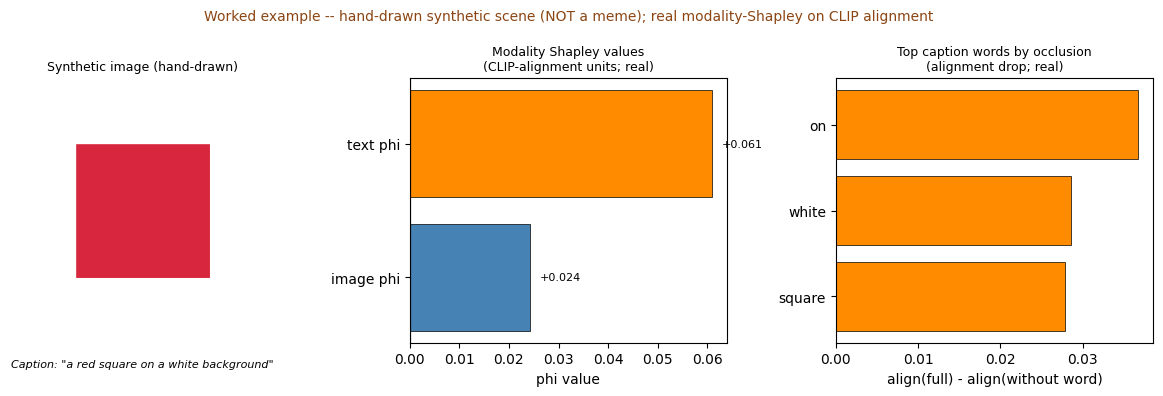


Worked-example attribution (real outputs of awake.eval.modality_shapley):
  phi_image   = +0.0242
  phi_text    = +0.0609
  total       = +0.0851   (= v({img,txt}) - v(empty), CLIP alignment)
  image share = +0.2843   (>0 = image-dominant, <0 = text-dominant)

  Caption words by leave-one-out alignment drop:
    'on': +0.0368
    'white': +0.0286
    'square': +0.0279
    'a': +0.0239
    'red': +0.0195
    'background': +0.0098
    'a': +0.0053

  Note: the value function here is CLIP image-text alignment (a stand-in for the
  gated hatefulness margin); the Shapley + occlusion CODE is the same as the pipeline.


In [11]:
# ---------------------------------------------------------------------------
# Render the worked example (synthetic image + real attribution outputs)
# ---------------------------------------------------------------------------
if _example_ok:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(
        "Worked example -- hand-drawn synthetic scene (NOT a meme); "
        "real modality-Shapley on CLIP alignment",
        fontsize=10,
        color="saddlebrown",
    )

    axes[0].imshow(np.asarray(_focal_img))
    axes[0].set_title("Synthetic image (hand-drawn)", fontsize=9)
    axes[0].axis("off")
    axes[0].text(
        0.5, -0.06, f'Caption: "{_focal_caption}"',
        ha="center", va="top", transform=axes[0].transAxes,
        fontsize=8, style="italic", wrap=True,
    )

    axes[1].barh(
        ["image phi", "text phi"], [_phi_image, _phi_text],
        color=["steelblue", "darkorange"], edgecolor="black", linewidth=0.5,
    )
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_title("Modality Shapley values\n(CLIP-alignment units; real)", fontsize=9)
    axes[1].set_xlabel("phi value")
    for _i, _v in enumerate([_phi_image, _phi_text]):
        axes[1].text(_v + (0.002 if _v >= 0 else -0.002), _i, f"{_v:+.3f}",
                     va="center", ha="left" if _v >= 0 else "right", fontsize=8)

    _tn = [t for t, _ in _word_imp[:3]]
    _ts = [s for _, s in _word_imp[:3]]
    axes[2].barh(_tn[::-1], _ts[::-1], color="darkorange", edgecolor="black", linewidth=0.5)
    axes[2].set_title("Top caption words by occlusion\n(alignment drop; real)", fontsize=9)
    axes[2].set_xlabel("align(full) - align(without word)")

    plt.tight_layout()
    plt.show()

    print("\nWorked-example attribution (real outputs of awake.eval.modality_shapley):")
    print(f"  phi_image   = {_phi_image:+.4f}")
    print(f"  phi_text    = {_phi_text:+.4f}")
    print(f"  total       = {_total:+.4f}   (= v({{img,txt}}) - v(empty), CLIP alignment)")
    print(f"  image share = {_share:+.4f}   (>0 = image-dominant, <0 = text-dominant)")
    print("\n  Caption words by leave-one-out alignment drop:")
    for _tok, _imp in _word_imp:
        print(f"    '{_tok}': {_imp:+.4f}")
    print(
        "\n  Note: the value function here is CLIP image-text alignment (a stand-in for the\n"
        "  gated hatefulness margin); the Shapley + occlusion CODE is the same as the pipeline."
    )

## 5. Discussion

_Full discussion is in `REPORT.md §6` and will be populated once the end-to-end
run completes.  The framing below describes what the results would show._

The **signed image share** `s` is the primary summary quantity.  A positive `s`
(image-dominant) means the CLIP image embedding carries more of the log-odds shift
from the background; a negative `s` (text-dominant) means the CLIP text embedding
does.  The aggregate over dev reveals the model's default modality reliance; the
per-label and per-correctness breakdowns reveal whether that reliance is consistent
across hateful and benign examples and whether failures cluster in one modality.

The **fused − unimodal AUROC gaps** (§1 above) quantify whether fusion actually helps.
A gap that straddles zero at n = 500 is inconclusive; a consistently positive gap
indicates the two modalities carry complementary signal that the fused head exploits.

### Key limitations to keep in mind

- The empirical background (~64% benign) makes `v(empty)` and absolute φ magnitudes
  prior-dependent.  The **signed image share `s`** normalises this away; the
  balanced-background ablation in `metrics.json` quantifies the residual shift.
- Factorised background pairs are off-manifold for the tree model.  The mean-baseline
  ablation in `metrics.json` quantifies the practical effect.
- The synthetic qualitative example above (cell 4) is illustrative only.  It uses
  Gaussian noise and a made-up caption — not a real meme — to demonstrate the output
  format without violating the HM licence.
- The Space uses CLIP-ViT-B/32 and a generic non-HM background; its attributions
  are illustrative and not numerically comparable to the L/14 headline.

See `REPORT.md §7` (Limitations) for the full list.